In [1]:
!pip uninstall torch torchvision torchaudio -y
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install thop torchmetrics seaborn scikit-learn pandas matplotlib

Found existing installation: torch 2.10.0+cu128
Uninstalling torch-2.10.0+cu128:
  Successfully uninstalled torch-2.10.0+cu128
Found existing installation: torchvision 0.25.0+cu128
Uninstalling torchvision-0.25.0+cu128:
  Successfully uninstalled torchvision-0.25.0+cu128
Found existing installation: torchaudio 2.10.0+cu128
Uninstalling torchaudio-2.10.0+cu128:
  Successfully uninstalled torchaudio-2.10.0+cu128
Looking in indexes: https://download.pytorch.org/whl/cu118
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 77.5 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 875.6/875.6 kB 45.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 98.0 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 663.9/663.9 MB 2.8 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 417.9/417.9 MB 3.6 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.4/168.4 MB 4.5 MB/s eta 0:00:0000

In [2]:
import os, time, torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models

from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             roc_auc_score, confusion_matrix, roc_curve, auc)
from sklearn.preprocessing import label_binarize

import matplotlib.pyplot as plt
import seaborn as sns
from thop import profile

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Parameters
data_dir = '/kaggle/input/datasets/nahidhasan007007/group-7/PRBD Microscopic Image of Different Processed Rice/Original Images'
input_size = 224
batch_size = 32
epochs = 50
seed = 42

torch.manual_seed(seed)
np.random.seed(seed)

In [3]:
# =========================
# Data Preparation (10:90)
# =========================

transform = transforms.Compose([
    transforms.Resize((input_size, input_size)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

full_dataset = datasets.ImageFolder(data_dir, transform=transform)

class_names = full_dataset.classes
num_classes = len(class_names)

# ---- 10% train+val, 90% test ----
test_size = int(0.90 * len(full_dataset))
train_val_size = len(full_dataset) - test_size

train_val_dataset, test_dataset = random_split(
    full_dataset,
    [train_val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

# ---- validation from train_val (10%) ----
val_size = int(0.10 * train_val_size)
train_size = train_val_size - val_size

train_dataset, val_dataset = random_split(
    train_val_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [4]:
print("Initializing ViT-B/16...")

model = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1)
model.heads.head = nn.Linear(model.heads.head.in_features, num_classes)

model = model.to(device)

Initializing ViT-B/16...
Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:02<00:00, 128MB/s]  


In [5]:
dummy_input = torch.randn(1, 3, 224, 224).to(device)

flops, _ = profile(model, inputs=(dummy_input,), verbose=False)
gflops = flops / 1e9

print(f"Model GFLOPs: {gflops:.4f}")

Model GFLOPs: 11.2855


In [6]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

print("Starting Training...")
start_time = time.time()

for epoch in range(epochs):

    # ---- Training ----
    model.train()
    running_loss, correct = 0.0, 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, 1)
        correct += torch.sum(preds == labels)

    train_loss = running_loss / len(train_dataset)
    train_acc = correct.double().item() / len(train_dataset)

    # ---- Validation ----
    model.eval()
    val_loss, val_correct = 0.0, 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            val_correct += torch.sum(preds == labels)

    val_loss /= len(val_dataset)
    val_acc = val_correct.double().item() / len(val_dataset)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f"Epoch {epoch+1}/{epochs} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

train_time = time.time() - start_time

Starting Training...
Epoch 1/50 | Train Acc: 0.2333 | Val Acc: 0.5500
Epoch 2/50 | Train Acc: 0.5778 | Val Acc: 0.7000
Epoch 3/50 | Train Acc: 0.7333 | Val Acc: 0.7500
Epoch 4/50 | Train Acc: 0.8556 | Val Acc: 0.8500
Epoch 5/50 | Train Acc: 0.9278 | Val Acc: 0.8500
Epoch 6/50 | Train Acc: 0.9444 | Val Acc: 0.8500
Epoch 7/50 | Train Acc: 0.9889 | Val Acc: 0.9000
Epoch 8/50 | Train Acc: 1.0000 | Val Acc: 0.8500
Epoch 9/50 | Train Acc: 1.0000 | Val Acc: 0.9500
Epoch 10/50 | Train Acc: 1.0000 | Val Acc: 0.8000
Epoch 11/50 | Train Acc: 1.0000 | Val Acc: 0.9000
Epoch 12/50 | Train Acc: 1.0000 | Val Acc: 0.9000
Epoch 13/50 | Train Acc: 1.0000 | Val Acc: 0.9000
Epoch 14/50 | Train Acc: 1.0000 | Val Acc: 0.9000
Epoch 15/50 | Train Acc: 1.0000 | Val Acc: 0.9000
Epoch 16/50 | Train Acc: 1.0000 | Val Acc: 0.9000
Epoch 17/50 | Train Acc: 1.0000 | Val Acc: 0.9000
Epoch 18/50 | Train Acc: 1.0000 | Val Acc: 0.9000
Epoch 19/50 | Train Acc: 1.0000 | Val Acc: 0.9000
Epoch 20/50 | Train Acc: 1.0000 | Val 

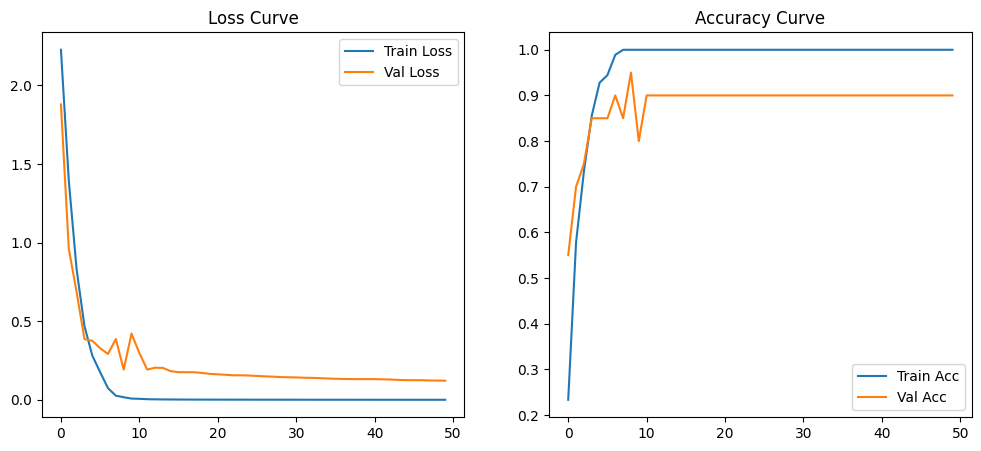

In [7]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title("Loss Curve")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history['train_acc'], label='Train Acc')
plt.plot(history['val_acc'], label='Val Acc')
plt.title("Accuracy Curve")
plt.legend()

plt.show()

In [8]:
model.eval()

y_true, y_pred, y_probs = [], [], []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)

        outputs = model(inputs)
        probs = torch.softmax(outputs, dim=1)

        _, preds = torch.max(outputs, 1)

        y_probs.extend(probs.cpu().numpy())
        y_true.extend(labels.numpy())
        y_pred.extend(preds.cpu().numpy())

y_probs = np.array(y_probs)

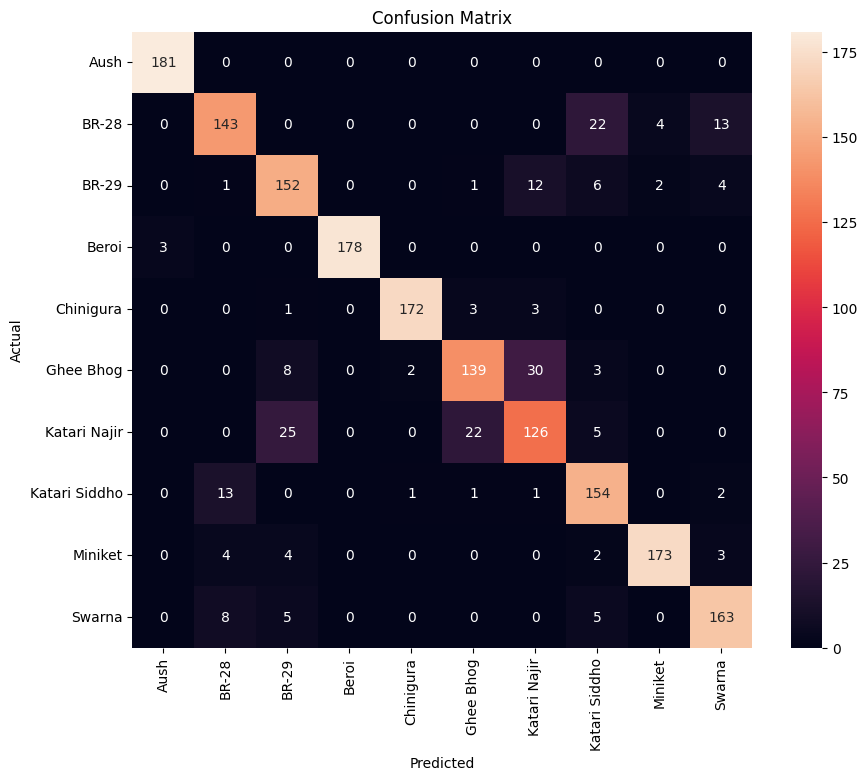

In [9]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

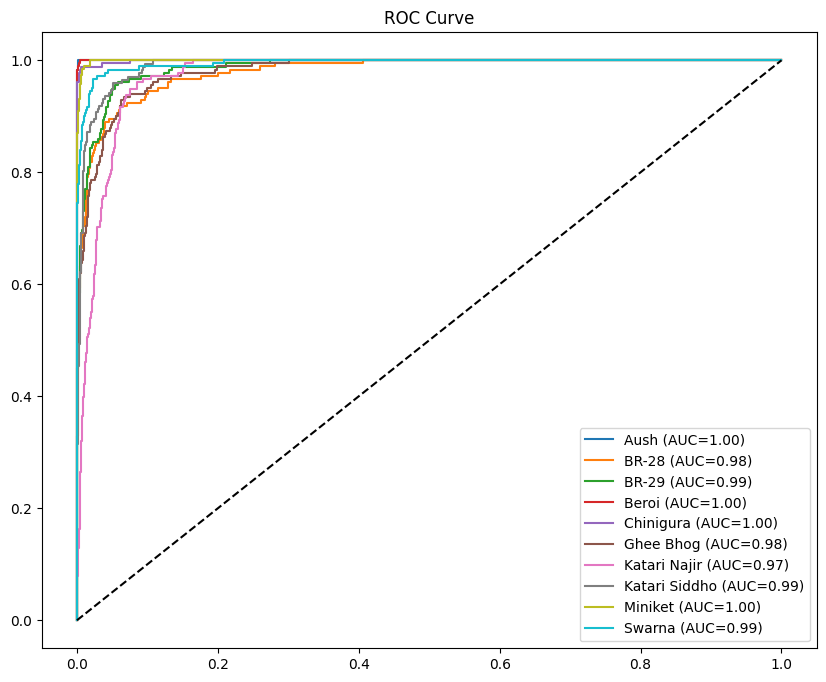

In [10]:
y_true_bin = label_binarize(y_true, classes=range(num_classes))

plt.figure(figsize=(10,8))

for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
    plt.plot(fpr, tpr, label=f"{class_names[i]} (AUC={auc(fpr,tpr):.2f})")

plt.plot([0,1],[0,1],'k--')
plt.legend()
plt.title("ROC Curve")
plt.show()

In [11]:
acc = accuracy_score(y_true, y_pred)
p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')
auc_score = roc_auc_score(y_true_bin, y_probs, multi_class='ovr')

print("\nFinal Results (ViT-B/16)")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {p:.4f}")
print(f"Recall   : {r:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {auc_score:.4f}")
print(f"GFLOPs   : {gflops:.4f}")
print(f"Train Time (s): {train_time:.2f}")


Final Results (ViT-B/16)
Accuracy : 0.8783
Precision: 0.8791
Recall   : 0.8782
F1 Score : 0.8777
ROC-AUC  : 0.9905
GFLOPs   : 11.2855
Train Time (s): 424.62
